# Hollow Rectangular Waveguide Modes

This notebook solves a PEC rectangular waveguide with `WaveguideModeSolver`, compares against analytic TE/TM modes, and plots the first fields.

In [1]:
import palacetoolkit as ptk

import gmsh
import numpy as np
import matplotlib.pyplot as plt

from palacetoolkit.mode_solver import WaveguideModeSolver
from palacetoolkit.utils import write_and_finalize_gmsh

In [2]:
def _set_transfinite_rect(surf_tag, nx, ny):
    bnd = gmsh.model.getBoundary([(2, surf_tag)], oriented=True)
    lines = [abs(t) for _, t in bnd]
    for line in lines:
        pts = gmsh.model.getBoundary([(1, line)], oriented=False)
        c0 = gmsh.model.getValue(0, pts[0][1], [])
        c1 = gmsh.model.getValue(0, pts[1][1], [])
        dx = abs(c1[0] - c0[0])
        dy = abs(c1[1] - c0[1])
        n = (nx + 1) if dx > dy else (ny + 1)
        gmsh.model.mesh.setTransfiniteCurve(line, n)
    gmsh.model.mesh.setTransfiniteSurface(surf_tag)


def make_rectangular_mesh(a, b, nx, ny, structured=True, lc=None, filename=None):
    gmsh.initialize()
    gmsh.option.setNumber("General.Verbosity", 0)
    gmsh.model.add("hollow_waveguide")

    gmsh.model.occ.addRectangle(0, 0, 0, a, b, tag=1)
    gmsh.model.occ.synchronize()

    gmsh.model.addPhysicalGroup(2, [1], tag=1, name="domain")
    bnd = gmsh.model.getBoundary([(2, 1)], oriented=False)
    bnd_tags = [abs(t) for _, t in bnd]
    gmsh.model.addPhysicalGroup(1, bnd_tags, tag=1, name="PEC")

    if structured:
        _set_transfinite_rect(1, nx, ny)
        gmsh.model.mesh.setRecombine(2, 1)
    else:
        _lc = lc if lc is not None else max(a / nx, b / ny)
        gmsh.option.setNumber("Mesh.CharacteristicLengthMin", 0.8 * _lc)
        gmsh.option.setNumber("Mesh.CharacteristicLengthMax", 1.2 * _lc)

    gmsh.model.mesh.generate(2)
    return write_and_finalize_gmsh(filename, prefix="wg_rect_")

In [3]:
def analytic_kn(a, b, omega, m_max=5, n_max=5, mu=1.0, eps=1.0):
    modes = []
    k0_sq = omega**2 * mu * eps

    for m in range(0, m_max + 1):
        for n in range(0, n_max + 1):
            if m == 0 and n == 0:
                continue
            kc_sq = (m * np.pi / a) ** 2 + (n * np.pi / b) ** 2
            kn = np.sqrt((k0_sq - kc_sq) + 0j)
            modes.append((f"TE{m}{n}", np.sqrt(kc_sq), kn))

    for m in range(1, m_max + 1):
        for n in range(1, n_max + 1):
            kc_sq = (m * np.pi / a) ** 2 + (n * np.pi / b) ** 2
            kn = np.sqrt((k0_sq - kc_sq) + 0j)
            modes.append((f"TM{m}{n}", np.sqrt(kc_sq), kn))

    modes.sort(key=lambda x: -x[2].real)
    return modes

In [4]:
a, b = 2.0, 1.0
mu, eps = 1.0, 1.0
c0 = 1.0 / np.sqrt(mu * eps)

fc_te10 = c0 * np.pi / a / (2 * np.pi)
f_op = 3.5 * fc_te10
omega = 2 * np.pi * f_op

analytic = analytic_kn(a, b, omega, m_max=4, n_max=4, mu=mu, eps=eps)
print("Top 8 analytic modes:")
for name, kc, kn in analytic[:8]:
    print(f"  {name:6s}: kc={kc:8.4f}, kn={kn.real:+10.6f}{kn.imag:+10.6f}j")

Top 8 analytic modes:
  TE10  : kc=  1.5708, kn= +5.268611 +0.000000j
  TE01  : kc=  3.1416, kn= +4.511769 +0.000000j
  TE20  : kc=  3.1416, kn= +4.511769 +0.000000j
  TE11  : kc=  3.5124, kn= +4.229499 +0.000000j
  TM11  : kc=  3.5124, kn= +4.229499 +0.000000j
  TE21  : kc=  4.4429, kn= +3.238280 +0.000000j
  TM21  : kc=  4.4429, kn= +3.238280 +0.000000j
  TE30  : kc=  4.7124, kn= +2.831793 +0.000000j


In [5]:
mesh_file = make_rectangular_mesh(a, b, nx=32, ny=16, structured=True)
solver = WaveguideModeSolver(mesh_file, order=2, mu_inv=1.0 / mu, eps=eps, pec_bdr="all")
results = solver.solve(omega, num_modes=8, mode_idx=1)

print("\nNumerical modes:")
for i, kn in enumerate(results["kn"], start=1):
    print(f"  Mode {i}: kn={kn.real:+10.6f}{kn.imag:+10.6f}j")

  FE spaces: ND dofs = 4192, H1 dofs = 2145, total = 6337
  Essential DOFs: ND = 192, H1 = 192, total = 384


  Solving eigenvalue problem (omega = 5.49779, sigma = -33.2482, size = 6337)...
  Found 8 modes:
    Mode 1: kn = +5.26861102e+00 -0.00000000e+00j <-- selected
    Mode 2: kn = +4.51176670e+00 -0.00000000e+00j
    Mode 3: kn = +4.51176670e+00 -0.00000000e+00j
    Mode 4: kn = +4.22949611e+00 -0.00000000e+00j
    Mode 5: kn = +4.22949611e+00 -0.00000000e+00j
    Mode 6: kn = +3.23827331e+00 -0.00000000e+00j
    Mode 7: kn = +3.23827331e+00 -0.00000000e+00j
    Mode 8: kn = +2.83175256e+00 -0.00000000e+00j

Numerical modes:
  Mode 1: kn= +5.268611 -0.000000j
  Mode 2: kn= +4.511767 -0.000000j
  Mode 3: kn= +4.511767 -0.000000j
  Mode 4: kn= +4.229496 -0.000000j
  Mode 5: kn= +4.229496 -0.000000j
  Mode 6: kn= +3.238273 -0.000000j
  Mode 7: kn= +3.238273 -0.000000j
  Mode 8: kn= +2.831753 -0.000000j


  Solving eigenvalue problem (omega = 5.49779, sigma = -33.2482, size = 6337)...
  Found 8 modes:
    Mode 1: kn = +5.26861102e+00 -0.00000000e+00j <-- selected
    Mode 2: kn = +4.51176670e+00 -0.00000000e+00j
    Mode 3: kn = +4.51176670e+00 -0.00000000e+00j
    Mode 4: kn = +4.22949611e+00 -0.00000000e+00j
    Mode 5: kn = +4.22949611e+00 -0.00000000e+00j
    Mode 6: kn = +3.23827331e+00 -0.00000000e+00j
    Mode 7: kn = +3.23827331e+00 -0.00000000e+00j
    Mode 8: kn = +2.83175256e+00 -0.00000000e+00j


  Solving eigenvalue problem (omega = 5.49779, sigma = -33.2482, size = 6337)...
  Found 8 modes:
    Mode 1: kn = +5.26861102e+00 -0.00000000e+00j
    Mode 2: kn = +4.51176670e+00 -0.00000000e+00j <-- selected
    Mode 3: kn = +4.51176670e+00 -0.00000000e+00j
    Mode 4: kn = +4.22949611e+00 -0.00000000e+00j
    Mode 5: kn = +4.22949611e+00 -0.00000000e+00j
    Mode 6: kn = +3.23827331e+00 -0.00000000e+00j
    Mode 7: kn = +3.23827331e+00 -0.00000000e+00j
    Mode 8: kn = +2.83175256e+00 -0.00000000e+00j


  Solving eigenvalue problem (omega = 5.49779, sigma = -33.2482, size = 6337)...
  Found 8 modes:
    Mode 1: kn = +5.26861102e+00 -0.00000000e+00j
    Mode 2: kn = +4.51176670e+00 -0.00000000e+00j
    Mode 3: kn = +4.51176670e+00 -0.00000000e+00j <-- selected
    Mode 4: kn = +4.22949611e+00 -0.00000000e+00j
    Mode 5: kn = +4.22949611e+00 -0.00000000e+00j
    Mode 6: kn = +3.23827331e+00 -0.00000000e+00j
    Mode 7: kn = +3.23827331e+00 -0.00000000e+00j
    Mode 8: kn = +2.83175256e+00 -0.00000000e+00j


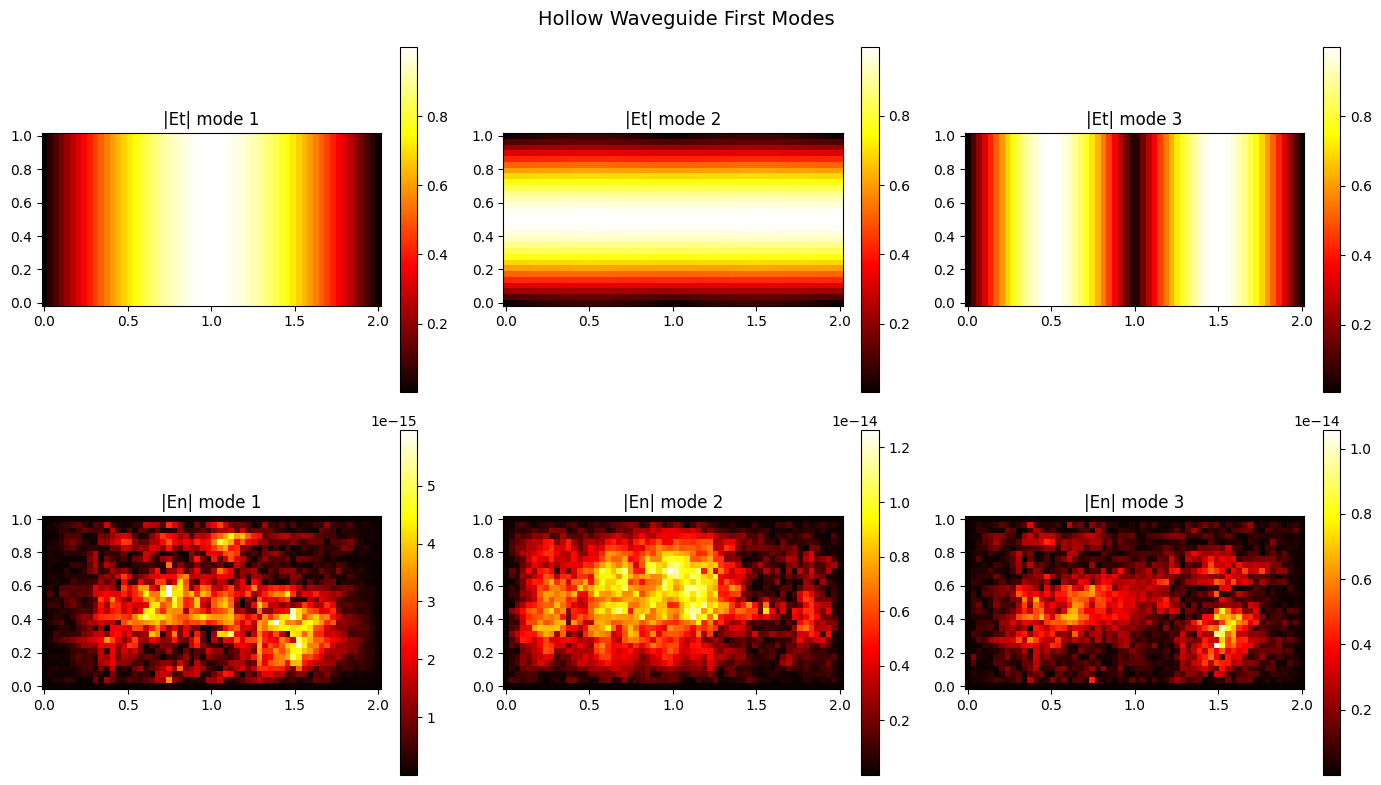

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle("Hollow Waveguide First Modes", fontsize=14)

for mode_i in range(3):
    r = solver.solve(omega, num_modes=8, mode_idx=mode_i + 1)
    X, Y, Ex, Ey, Ez = solver.get_field_on_grid(r["Et_vec"], r["En_vec"], nx=60, ny=30)

    Et_mag = np.sqrt(np.abs(Ex) ** 2 + np.abs(Ey) ** 2)
    En_mag = np.abs(Ez)

    ax = axes[0, mode_i]
    im = ax.pcolormesh(X, Y, Et_mag, cmap="hot", shading="auto")
    ax.set_title(f"|Et| mode {mode_i+1}")
    ax.set_aspect("equal")
    fig.colorbar(im, ax=ax, fraction=0.046)

    ax = axes[1, mode_i]
    im = ax.pcolormesh(X, Y, En_mag, cmap="hot", shading="auto")
    ax.set_title(f"|En| mode {mode_i+1}")
    ax.set_aspect("equal")
    fig.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()